In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import warnings
import time
import platform
import sys
import psutil
import subprocess
warnings.filterwarnings('ignore')

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:
df = pd.read_csv('/content/fertilizer_dataset.csv')

✓ Saved: fertilizer_data_analysis.png


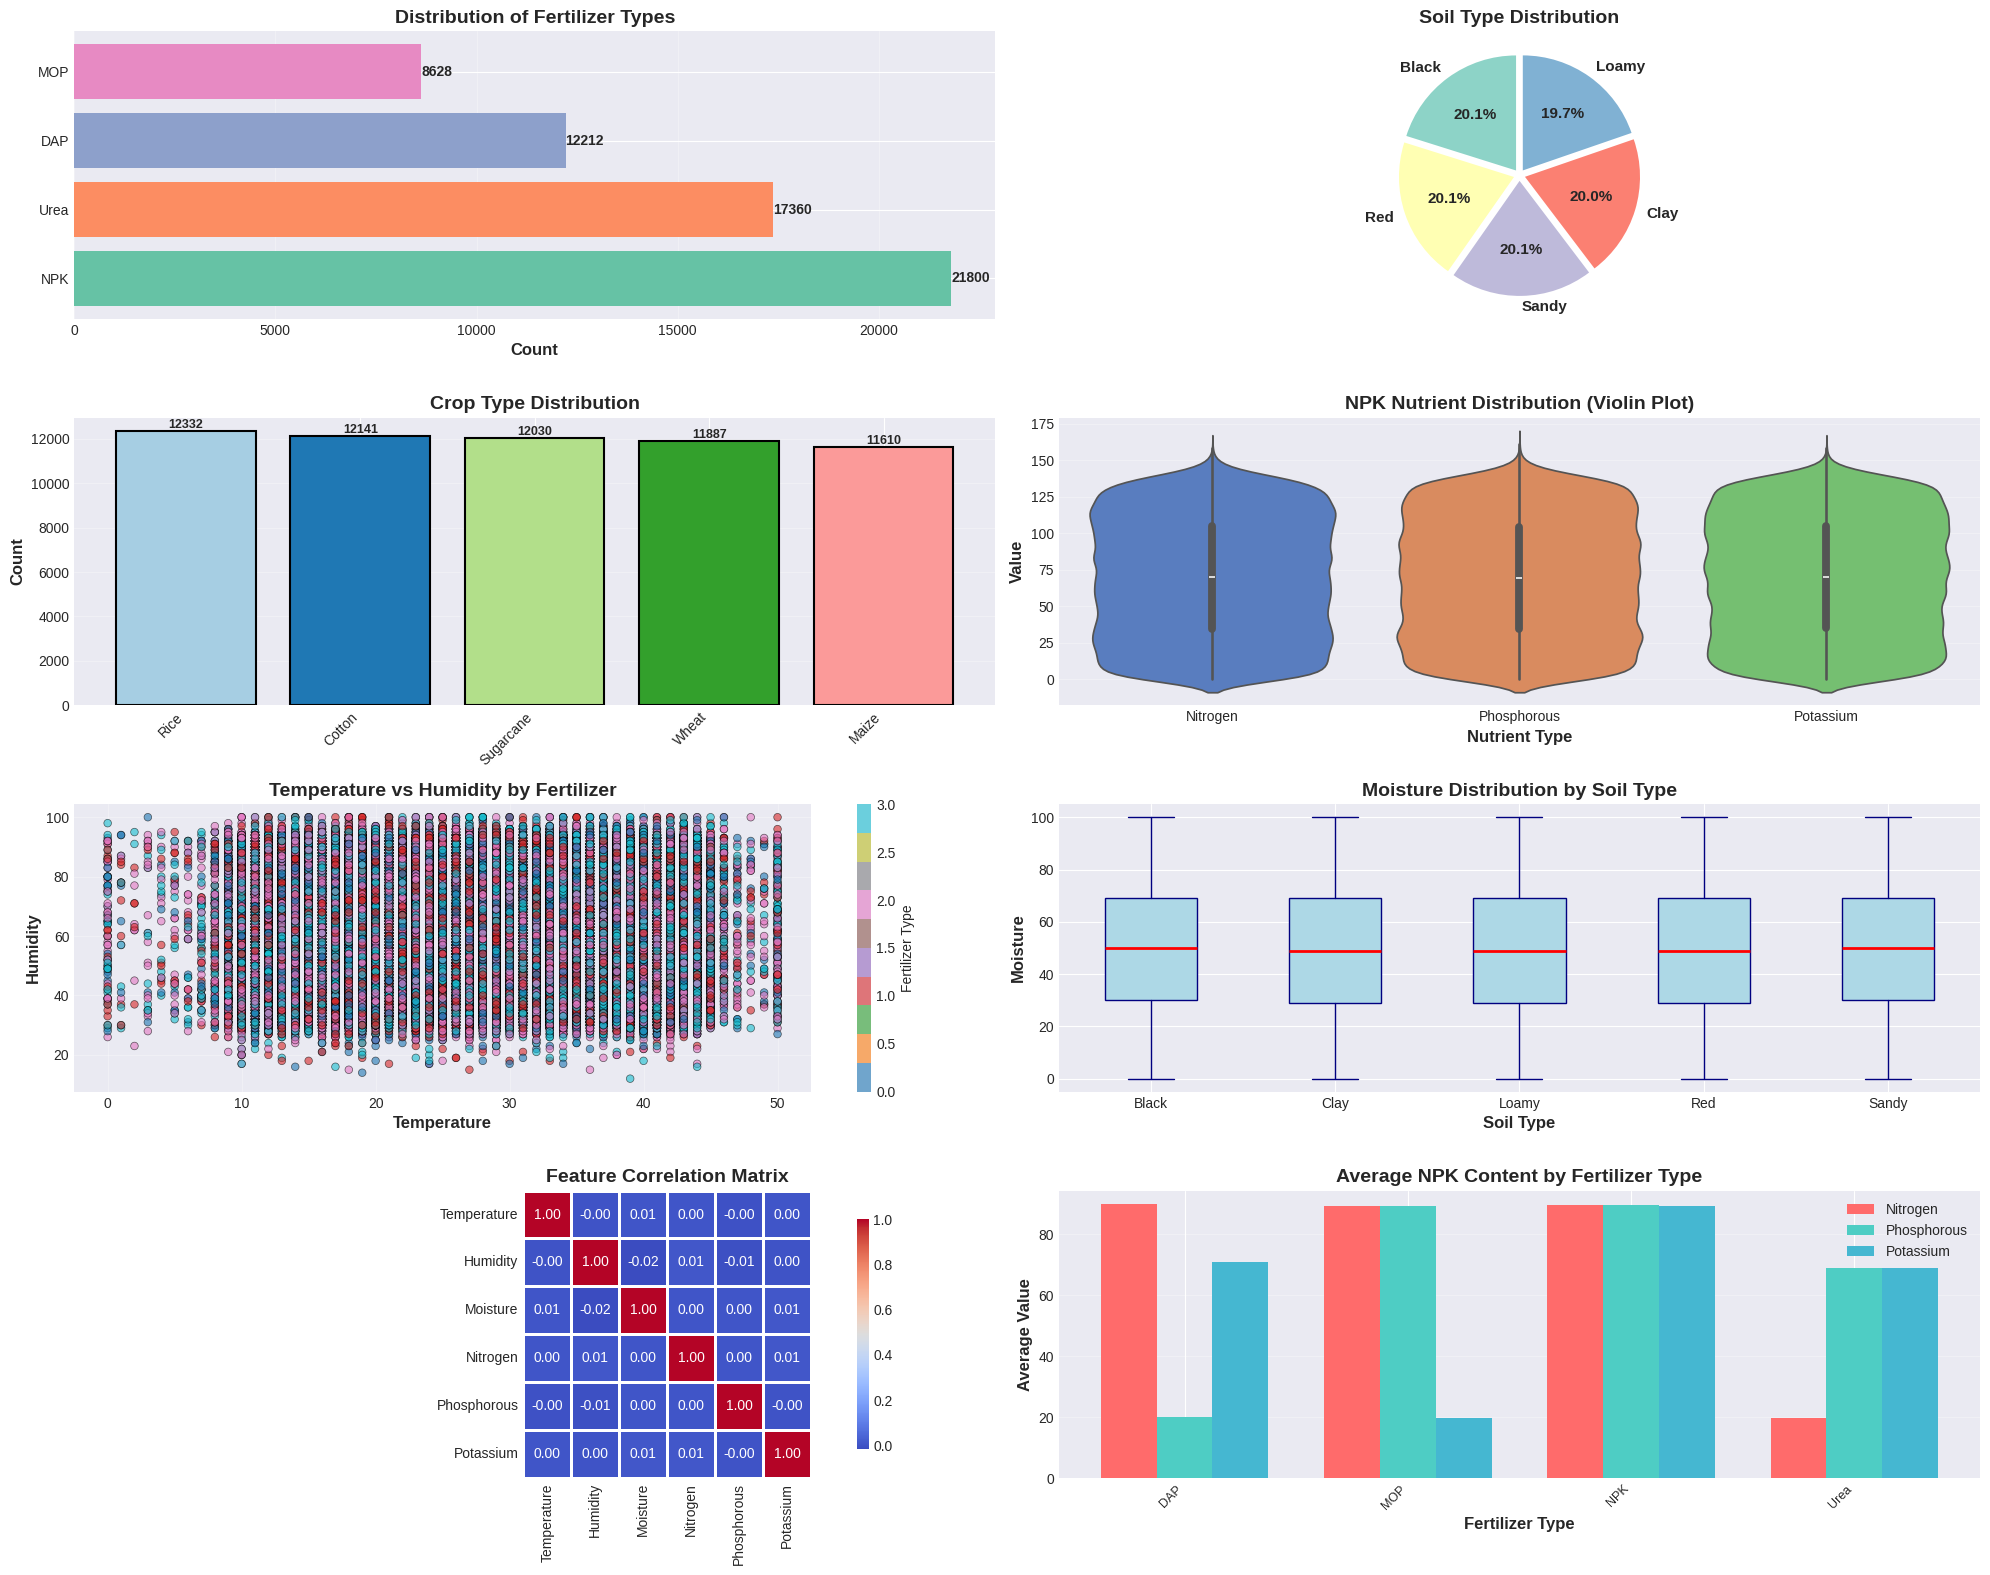

In [ ]:
# FIGURE 1: DATA EXPLORATION DASHBOARD (4x2 grid)
fig1 = plt.figure(figsize=(20, 16))
fig1.suptitle('Fertilizer Prediction Dataset - Comprehensive Analysis',
              fontsize=24, fontweight='bold', y=0.995)

# 1. Fertilizer Distribution
ax1 = plt.subplot(4, 2, 1)
fertilizer_counts = df['Fertilizer Name'].value_counts()
colors = sns.color_palette("Set2", len(fertilizer_counts))
bars = ax1.barh(fertilizer_counts.index, fertilizer_counts.values, color=colors)
ax1.set_xlabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Fertilizer Types', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width, bar.get_y() + bar.get_height()/2, f'{int(width)}',
             ha='left', va='center', fontweight='bold', fontsize=10)

# 2. Soil Type Distribution
ax2 = plt.subplot(4, 2, 2)
soil_counts = df['Soil Type'].value_counts()
explode = [0.05] * len(soil_counts)
colors_soil = sns.color_palette("Set3", len(soil_counts))
wedges, texts, autotexts = ax2.pie(soil_counts.values, labels=soil_counts.index,
                                     autopct='%1.1f%%', startangle=90,
                                     explode=explode, colors=colors_soil,
                                     textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Soil Type Distribution', fontsize=14, fontweight='bold')

# 3. Crop Type Distribution
ax3 = plt.subplot(4, 2, 3)
crop_counts = df['Crop Type'].value_counts()
colors_crop = sns.color_palette("Paired", len(crop_counts))
bars = ax3.bar(range(len(crop_counts)), crop_counts.values, color=colors_crop, edgecolor='black', linewidth=1.5)
ax3.set_xticks(range(len(crop_counts)))
ax3.set_xticklabels(crop_counts.index, rotation=45, ha='right', fontsize=10)
ax3.set_ylabel('Count', fontsize=12, fontweight='bold')
ax3.set_title('Crop Type Distribution', fontsize=14, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# 4. NPK Distribution (Violin Plot)
ax4 = plt.subplot(4, 2, 4)
npk_data = pd.DataFrame({
    'Nutrient': ['Nitrogen']*len(df) + ['Phosphorous']*len(df) + ['Potassium']*len(df),
    'Value': list(df['Nitrogen']) + list(df['Phosphorous']) + list(df['Potassium'])
})
sns.violinplot(data=npk_data, x='Nutrient', y='Value', ax=ax4, palette='muted')
ax4.set_title('NPK Nutrient Distribution (Violin Plot)', fontsize=14, fontweight='bold')
ax4.set_ylabel('Value', fontsize=12, fontweight='bold')
ax4.set_xlabel('Nutrient Type', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# 5. Temperature vs Humidity (Scatter)
ax5 = plt.subplot(4, 2, 5)
scatter = ax5.scatter(df['Temperature'], df['Humidity'],
                     c=pd.factorize(df['Fertilizer Name'])[0],
                     cmap='tab10', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
ax5.set_xlabel('Temperature', fontsize=12, fontweight='bold')
ax5.set_ylabel('Humidity', fontsize=12, fontweight='bold')
ax5.set_title('Temperature vs Humidity by Fertilizer', fontsize=14, fontweight='bold')
ax5.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax5, label='Fertilizer Type')

# 6. Moisture Distribution by Soil Type
ax6 = plt.subplot(4, 2, 6)
df.boxplot(column='Moisture', by='Soil Type', ax=ax6, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='navy'),
           capprops=dict(color='navy'))
ax6.set_title('Moisture Distribution by Soil Type', fontsize=14, fontweight='bold')
ax6.set_xlabel('Soil Type', fontsize=12, fontweight='bold')
ax6.set_ylabel('Moisture', fontsize=12, fontweight='bold')
plt.suptitle('')

# 7. Correlation Heatmap
ax7 = plt.subplot(4, 2, 7)
numeric_cols = ['Temperature', 'Humidity', 'Moisture', 'Nitrogen', 'Phosphorous', 'Potassium']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax7)
ax7.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

# 8. Average NPK by Fertilizer Type
ax8 = plt.subplot(4, 2, 8)
npk_by_fert = df.groupby('Fertilizer Name')[['Nitrogen', 'Phosphorous', 'Potassium']].mean()
x = np.arange(len(npk_by_fert))
width = 0.25
bars1 = ax8.bar(x - width, npk_by_fert['Nitrogen'], width, label='Nitrogen', color='#FF6B6B')
bars2 = ax8.bar(x, npk_by_fert['Phosphorous'], width, label='Phosphorous', color='#4ECDC4')
bars3 = ax8.bar(x + width, npk_by_fert['Potassium'], width, label='Potassium', color='#45B7D1')
ax8.set_xlabel('Fertilizer Type', fontsize=12, fontweight='bold')
ax8.set_ylabel('Average Value', fontsize=12, fontweight='bold')
ax8.set_title('Average NPK Content by Fertilizer Type', fontsize=14, fontweight='bold')
ax8.set_xticks(x)
ax8.set_xticklabels(npk_by_fert.index, rotation=45, ha='right', fontsize=9)
ax8.legend(loc='upper right', fontsize=10)
ax8.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fertilizer_data_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: fertilizer_data_analysis.png")

In [ ]:
X = df.drop("Fertilizer Name", axis=1)
y = df["Fertilizer Name"]
X_train_pre_encode, X_test_pre_encode, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

label_encoders = {}
for col in X_train_pre_encode.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X_train_pre_encode[col] = le.fit_transform(X_train_pre_encode[col])
    X_test_pre_encode[col] = le.transform(X_test_pre_encode[col])
    label_encoders[col] = le
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

label_encoders['Fertilizer Name'] = target_encoder
X_train = X_train_pre_encode
X_test = X_test_pre_encode
gpu_available = False
try:
    subprocess.check_output('nvidia-smi', stderr=subprocess.STDOUT)
    gpu_available = True
    device_used = 'GPU'
    print("GPU detected. XGBoost will attempt to use GPU.")
except (subprocess.CalledProcessError, FileNotFoundError):
    device_used = 'CPU'
    print("No GPU detected or nvidia-smi not found. XGBoost will use CPU.")

model_params = {
    'n_estimators': 300,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'objective': "multi:softmax",
    'eval_metric': "mlogloss",
    'random_state': 42
}
if gpu_available:
    model_params['tree_method'] = 'gpu_hist'
model = XGBClassifier(**model_params)
print("\nTraining model...")
start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()
training_time_seconds = end_time - start_time
print(f"Training complete in {training_time_seconds:.2f} seconds using {device_used}.")
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)
train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

No GPU detected or nvidia-smi not found. XGBoost will use CPU.

Training model...
Training complete in 5.23 seconds using CPU.
Training Accuracy: 0.9653
Test Accuracy: 0.9503


✓ Saved: fertilizer_model_performance.png
✓ Saved: fertilizer_advanced_insights.png

ALL VISUALIZATIONS CREATED SUCCESSFULLY!

Generated Files:
1. fertilizer_data_analysis.png - Comprehensive data exploration
2. fertilizer_model_performance.png - Model performance metrics
3. fertilizer_advanced_insights.png - Advanced feature analysis


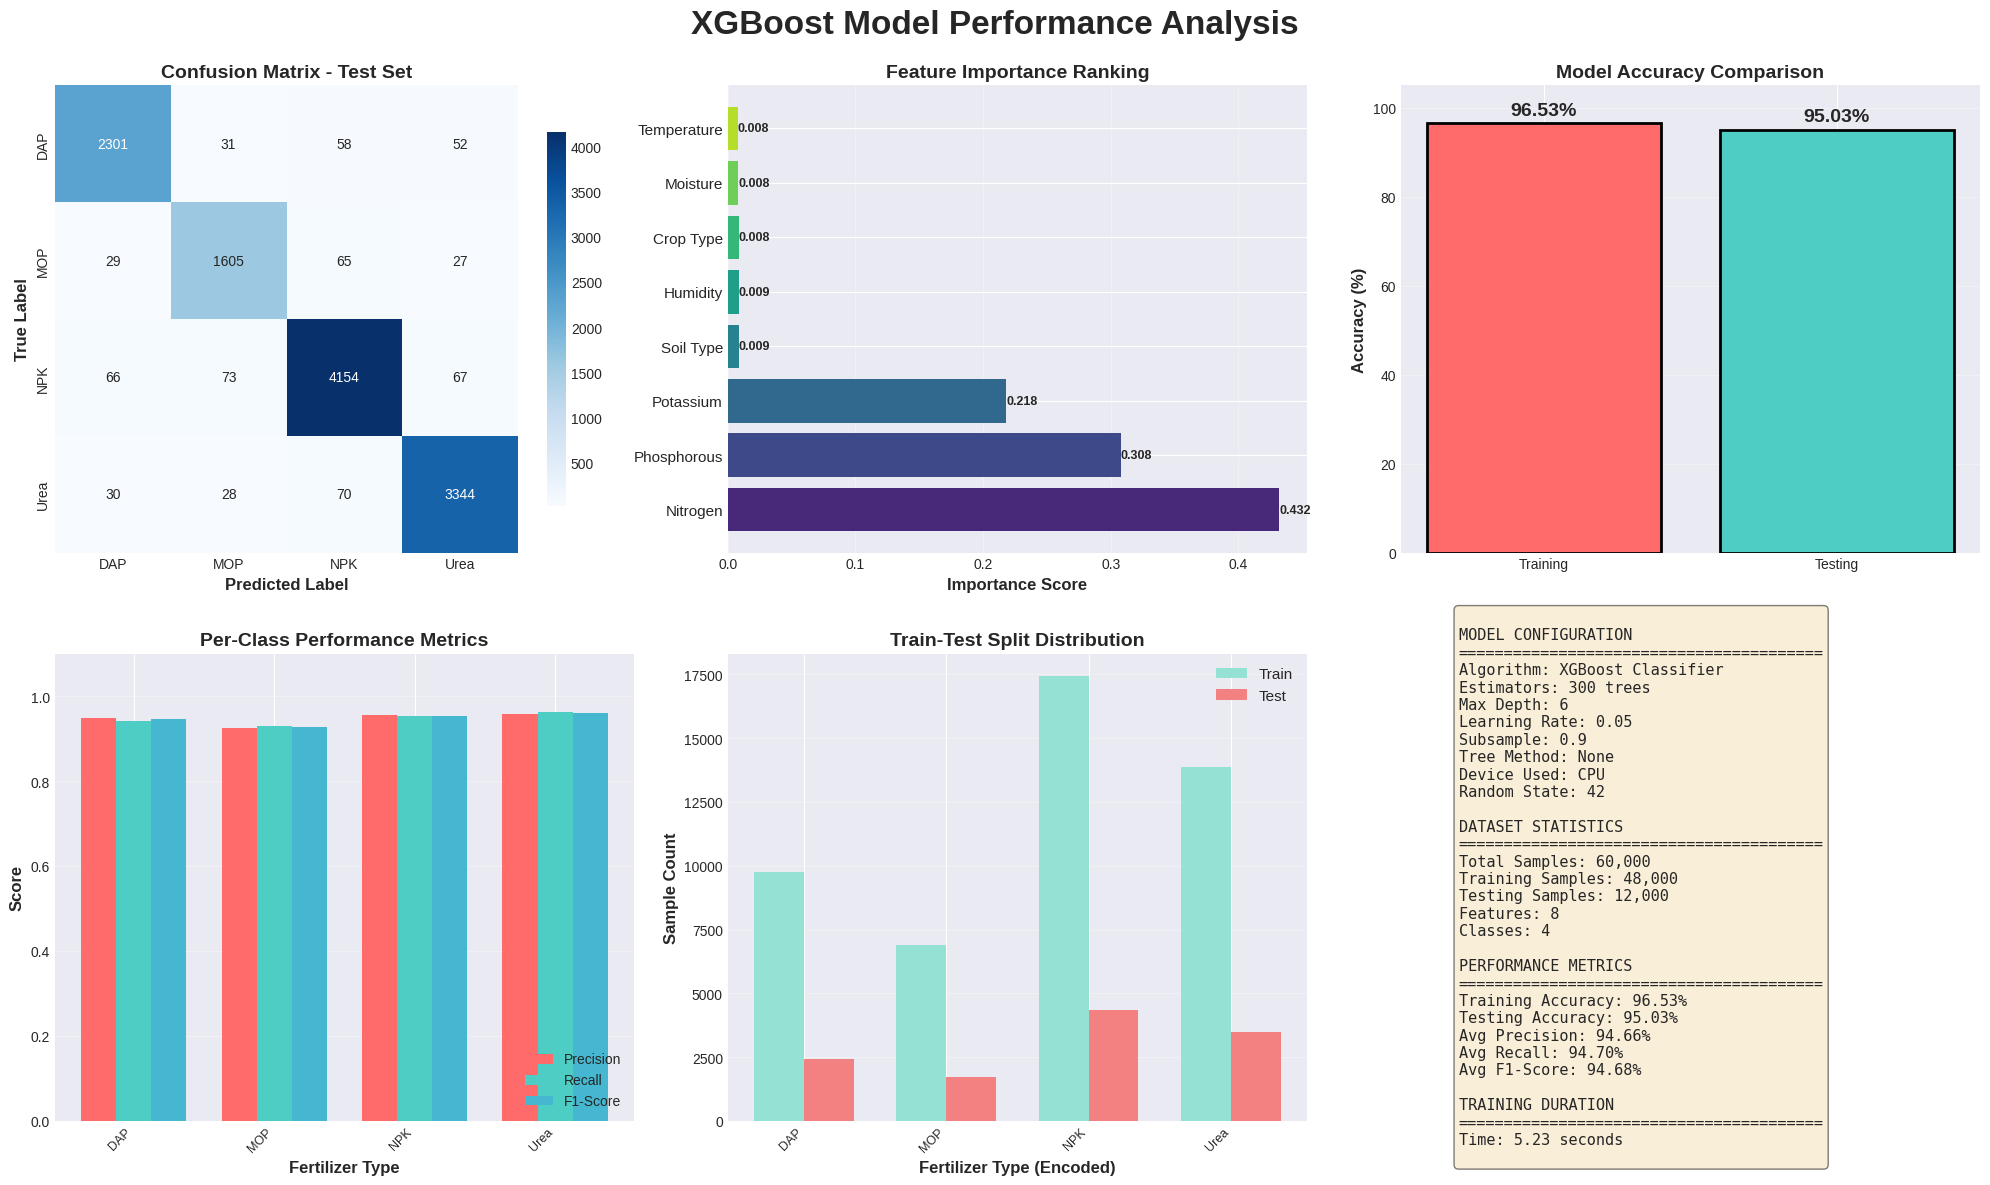

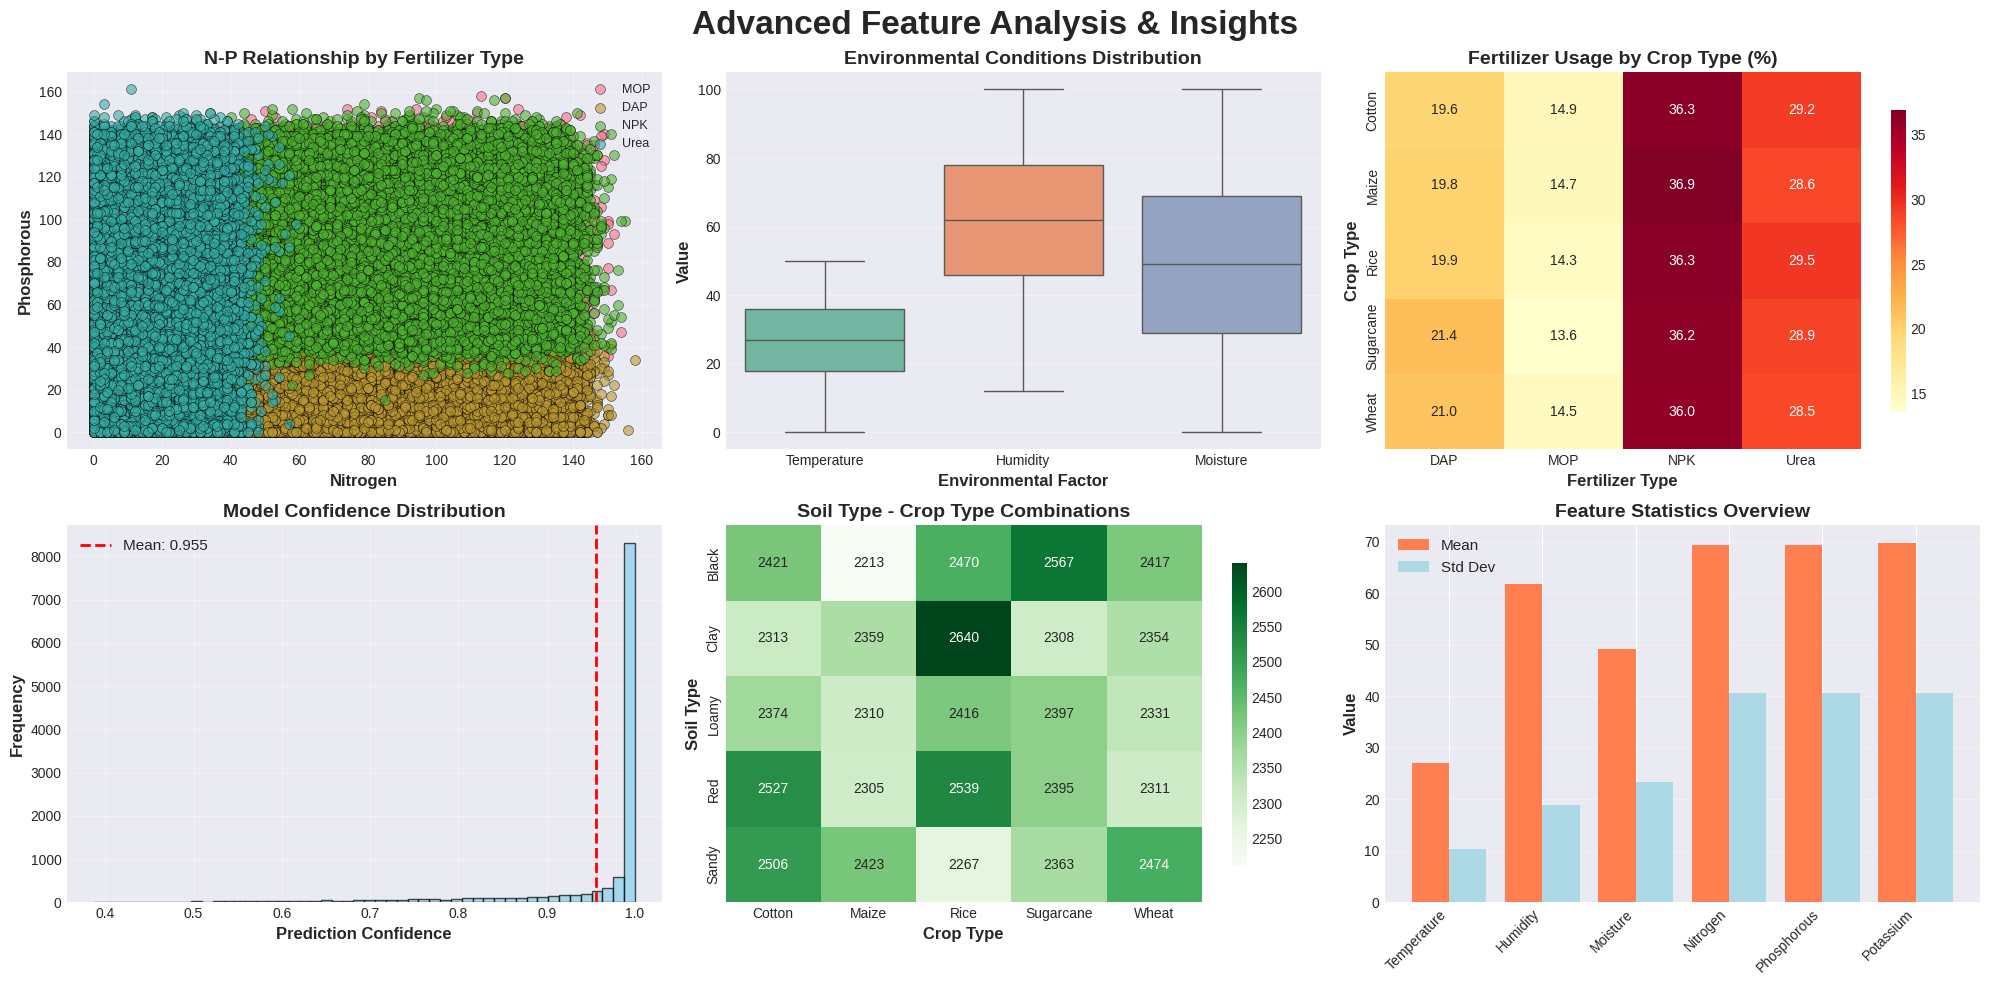

In [ ]:
fig2 = plt.figure(figsize=(20, 12))
fig2.suptitle('XGBoost Model Performance Analysis',
              fontsize=24, fontweight='bold', y=0.995)
# 1. Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_,
            cbar_kws={"shrink": 0.8}, ax=ax1)
ax1.set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
ax1.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')

# 2. Feature Importance
ax2 = plt.subplot(2, 3, 2)
feature_importance = model.feature_importances_
features = X.columns
indices = np.argsort(feature_importance)[::-1]
colors_feat = sns.color_palette("viridis", len(features))
bars = ax2.barh(range(len(features)), feature_importance[indices], color=colors_feat)
ax2.set_yticks(range(len(features)))
ax2.set_yticklabels([features[i] for i in indices], fontsize=11)
ax2.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax2.set_title('Feature Importance Ranking', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2, f'{width:.3f}',
             ha='left', va='center', fontweight='bold', fontsize=9)

# 3. Accuracy Comparison
ax3 = plt.subplot(2, 3, 3)
accuracies = [train_acc * 100, test_acc * 100]
labels = ['Training', 'Testing']
colors_acc = ['#FF6B6B', '#4ECDC4']
bars = ax3.bar(labels, accuracies, color=colors_acc, edgecolor='black', linewidth=2)
ax3.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax3.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax3.set_ylim([0, 105])
ax3.grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.2f}%', ha='center', va='bottom',
             fontweight='bold', fontsize=14)

# 4. Per-Class Accuracy
ax4 = plt.subplot(2, 3, 4)
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, test_preds, average=None, labels=range(len(target_encoder.classes_))
)
x = np.arange(len(target_encoder.classes_))
width = 0.25
bars1 = ax4.bar(x - width, precision, width, label='Precision', color='#FF6B6B')
bars2 = ax4.bar(x, recall, width, label='Recall', color='#4ECDC4')
bars3 = ax4.bar(x + width, f1, width, label='F1-Score', color='#45B7D1')
ax4.set_xlabel('Fertilizer Type', fontsize=12, fontweight='bold')
ax4.set_ylabel('Score', fontsize=12, fontweight='bold')
ax4.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(target_encoder.classes_, rotation=45, ha='right', fontsize=9)
ax4.legend(loc='lower right', fontsize=10)
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([0, 1.1])

# 5. Class Distribution (Train vs Test)
ax5 = plt.subplot(2, 3, 5)
train_dist = pd.Series(y_train).value_counts().sort_index()
test_dist = pd.Series(y_test).value_counts().sort_index()
x = np.arange(len(target_encoder.classes_))
width = 0.35
bars1 = ax5.bar(x - width/2, train_dist.values, width, label='Train', color='#95E1D3')
bars2 = ax5.bar(x + width/2, test_dist.values, width, label='Test', color='#F38181')
ax5.set_xlabel('Fertilizer Type (Encoded)', fontsize=12, fontweight='bold')
ax5.set_ylabel('Sample Count', fontsize=12, fontweight='bold')
ax5.set_title('Train-Test Split Distribution', fontsize=14, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(target_encoder.classes_, rotation=45, ha='right', fontsize=9)
ax5.legend(fontsize=11)
ax5.grid(axis='y', alpha=0.3)

# 6. Model Statistics Summary
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
stats_text = f"""
MODEL CONFIGURATION
{'='*40}
Algorithm: XGBoost Classifier
Estimators: {model.n_estimators} trees
Max Depth: {model.max_depth}
Learning Rate: {model.learning_rate}
Subsample: {model.subsample}
Tree Method: {getattr(model, 'tree_method', 'auto')}
Device Used: {device_used}
Random State: {model.random_state}

DATASET STATISTICS
{'='*40}
Total Samples: {len(df):,}
Training Samples: {len(X_train):,}
Testing Samples: {len(X_test):,}
Features: {X.shape[1]}
Classes: {len(target_encoder.classes_)}

PERFORMANCE METRICS
{'='*40}
Training Accuracy: {train_acc*100:.2f}%
Testing Accuracy: {test_acc*100:.2f}%
Avg Precision: {precision.mean()*100:.2f}%
Avg Recall: {recall.mean()*100:.2f}%
Avg F1-Score: {f1.mean()*100:.2f}%

TRAINING DURATION
{'='*40}
Time: {training_time_seconds:.2f} seconds
"""
ax6.text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round',
         facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('fertilizer_model_performance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: fertilizer_model_performance.png")

# FIGURE 3: ADVANCED INSIGHTS

fig3 = plt.figure(figsize=(20, 10))
fig3.suptitle('Advanced Feature Analysis & Insights',
              fontsize=24, fontweight='bold', y=0.98)

# 1. NPK Ratio Analysis by Fertilizer
ax1 = plt.subplot(2, 3, 1)
fertilizers = df['Fertilizer Name'].unique()
for fert in fertilizers[:5]:
    fert_data = df[df['Fertilizer Name'] == fert]
    ax1.scatter(fert_data['Nitrogen'], fert_data['Phosphorous'],
               label=fert, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Nitrogen', fontsize=12, fontweight='bold')
ax1.set_ylabel('Phosphorous', fontsize=12, fontweight='bold')
ax1.set_title('N-P Relationship by Fertilizer Type', fontsize=14, fontweight='bold')
ax1.legend(fontsize=9, loc='best')
ax1.grid(alpha=0.3)

# 2. Environmental Conditions Distribution
ax2 = plt.subplot(2, 3, 2)
env_data = pd.DataFrame({
    'Condition': ['Temperature']*len(df) + ['Humidity']*len(df) + ['Moisture']*len(df),
    'Value': list(df['Temperature']) + list(df['Humidity']) + list(df['Moisture'])
})
sns.boxplot(data=env_data, x='Condition', y='Value', ax=ax2, palette='Set2')
ax2.set_title('Environmental Conditions Distribution', fontsize=14, fontweight='bold')
ax2.set_ylabel('Value', fontsize=12, fontweight='bold')
ax2.set_xlabel('Environmental Factor', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Fertilizer Recommendations by Crop
ax3 = plt.subplot(2, 3, 3)
crop_fert = pd.crosstab(df['Crop Type'], df['Fertilizer Name'])
crop_fert_pct = crop_fert.div(crop_fert.sum(axis=1), axis=0) * 100
sns.heatmap(crop_fert_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={"shrink": 0.8}, ax=ax3)
ax3.set_title('Fertilizer Usage by Crop Type (%)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Fertilizer Type', fontsize=12, fontweight='bold')
ax3.set_ylabel('Crop Type', fontsize=12, fontweight='bold')

# 4. Prediction Confidence Distribution
ax4 = plt.subplot(2, 3, 4)
test_proba = model.predict_proba(X_test)
max_proba = test_proba.max(axis=1)
ax4.hist(max_proba, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax4.axvline(max_proba.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {max_proba.mean():.3f}')
ax4.set_xlabel('Prediction Confidence', fontsize=12, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax4.set_title('Model Confidence Distribution', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(alpha=0.3)

# 5. Soil-Crop Combination Heatmap
ax5 = plt.subplot(2, 3, 5)
soil_crop = pd.crosstab(df['Soil Type'], df['Crop Type'])
sns.heatmap(soil_crop, annot=True, fmt='d', cmap='Greens',
            cbar_kws={"shrink": 0.8}, ax=ax5)
ax5.set_title('Soil Type - Crop Type Combinations', fontsize=14, fontweight='bold')
ax5.set_xlabel('Crop Type', fontsize=12, fontweight='bold')
ax5.set_ylabel('Soil Type', fontsize=12, fontweight='bold')

# 6. Feature Distribution Comparison
ax6 = plt.subplot(2, 3, 6)
feature_stats = df[numeric_cols].describe().loc[['mean', 'std']].T
x = np.arange(len(feature_stats))
bars1 = ax6.bar(x - 0.2, feature_stats['mean'], 0.4, label='Mean', color='coral')
bars2 = ax6.bar(x + 0.2, feature_stats['std'], 0.4, label='Std Dev', color='lightblue')
ax6.set_xticks(x)
ax6.set_xticklabels(feature_stats.index, rotation=45, ha='right', fontsize=10)
ax6.set_ylabel('Value', fontsize=12, fontweight='bold')
ax6.set_title('Feature Statistics Overview', fontsize=14, fontweight='bold')
ax6.legend(fontsize=11)
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fertilizer_advanced_insights.png', dpi=300, bbox_inches='tight')
print("✓ Saved: fertilizer_advanced_insights.png")

print("\n" + "="*60)
print("ALL VISUALIZATIONS CREATED SUCCESSFULLY!")
print("="*60)
print("\nGenerated Files:")
print("1. fertilizer_data_analysis.png - Comprehensive data exploration")
print("2. fertilizer_model_performance.png - Model performance metrics")
print("3. fertilizer_advanced_insights.png - Advanced feature analysis")
print("="*60)

In [ ]:
import pickle
print("\nSaving model and encoders...")
with open('fertilizer_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print("Model saved as 'fertilizer_model.pkl'")
print("Encoders saved as 'label_encoders.pkl'")
print("\nAll done! ✓")


Saving model and encoders...
Model saved as 'fertilizer_model.pkl'
Encoders saved as 'label_encoders.pkl'

All done! ✓


In [ ]:
import pickle
import pandas as pd
import numpy as np

class FertilizerPredictor:
    def __init__(self, model_path='fertilizer_model.pkl', encoders_path='label_encoders.pkl'):
        """Load the trained model and encoders"""
        print("Loading model and encoders...")

        with open(model_path, 'rb') as f:
            self.model = pickle.load(f)

        with open(encoders_path, 'rb') as f:
            self.label_encoders = pickle.load(f)

        print("Model loaded successfully!\n")

    def predict(self, temperature, humidity, moisture, soil_type, crop_type,
                nitrogen, phosphorous, potassium):
        """
        Predict fertilizer based on input parameters

        Parameters:
        -----------
        temperature : int
        humidity : int
        moisture : int
        soil_type : str (e.g., 'Black', 'Red', 'Sandy', etc.)
        crop_type : str (e.g., 'Wheat', 'Rice', 'Maize', etc.)
        nitrogen : int
        phosphorous : int
        potassium : int

        Returns:
        --------
        str : Predicted fertilizer name
        """

        # Create input dataframe
        input_data = pd.DataFrame({
            'Temperature': [temperature],
            'Humidity': [humidity],
            'Moisture': [moisture],
            'Soil Type': [soil_type],
            'Crop Type': [crop_type],
            'Nitrogen': [nitrogen],
            'Phosphorous': [phosphorous],
            'Potassium': [potassium]
        })

        # Encode categorical features
        for col in ['Soil Type', 'Crop Type']:
            try:
                input_data[col] = self.label_encoders[col].transform(input_data[col])
            except ValueError as e:
                print(f"Error: '{input_data[col].values[0]}' is not a valid {col}")
                print(f"Valid options: {list(self.label_encoders[col].classes_)}")
                return None

        # Make prediction
        prediction_encoded = self.model.predict(input_data)

        # Decode prediction
        fertilizer = self.label_encoders['Fertilizer Name'].inverse_transform(prediction_encoded)[0]

        return fertilizer

    def predict_batch(self, input_list):
        """
        Predict fertilizer for multiple inputs

        Parameters:
        -----------
        input_list : list of dicts
            Each dict should have keys: temperature, humidity, moisture, soil_type,
            crop_type, nitrogen, phosphorous, potassium

        Returns:
        --------
        list : Predicted fertilizer names
        """
        predictions = []
        for inp in input_list:
            pred = self.predict(
                inp['temperature'], inp['humidity'], inp['moisture'],
                inp['soil_type'], inp['crop_type'], inp['nitrogen'],
                inp['phosphorous'], inp['potassium']
            )
            predictions.append(pred)
        return predictions


# Example usage
if __name__ == "__main__":
    # Initialize predictor
    predictor = FertilizerPredictor()

    # Example 1: Single prediction (your example)
    print("=" * 50)
    print("Example 1: Single Prediction")
    print("=" * 50)

    fertilizer = predictor.predict(
        temperature=38,
        humidity=42,
        moisture=88,
        soil_type='Black',
        crop_type='Wheat',
        nitrogen=137,
        phosphorous=99,
        potassium=58
    )

    print(f"\nInput:")
    print(f"  Temperature: 38")
    print(f"  Humidity: 42")
    print(f"  Moisture: 88")
    print(f"  Soil Type: Black")
    print(f"  Crop Type: Wheat")
    print(f"  Nitrogen: 137")
    print(f"  Phosphorous: 99")
    print(f"  Potassium: 58")
    print(f"\nPredicted Fertilizer: {fertilizer}")

    # Example 2: Batch prediction
    print("\n" + "=" * 50)
    print("Example 2: Batch Prediction")
    print("=" * 50)

    batch_inputs = [
        {
            'temperature': 38, 'humidity': 42, 'moisture': 88,
            'soil_type': 'Black', 'crop_type': 'Wheat',
            'nitrogen': 137, 'phosphorous': 99, 'potassium': 58
        },
        {
            'temperature': 25, 'humidity': 60, 'moisture': 45,
            'soil_type': 'Red', 'crop_type': 'Rice',
            'nitrogen': 80, 'phosphorous': 50, 'potassium': 40
        }
    ]

    predictions = predictor.predict_batch(batch_inputs)

    for i, pred in enumerate(predictions, 1):
        print(f"\nSample {i}: Predicted Fertilizer = {pred}")

Loading model and encoders...
Model loaded successfully!

Example 1: Single Prediction

Input:
  Temperature: 38
  Humidity: 42
  Moisture: 88
  Soil Type: Black
  Crop Type: Wheat
  Nitrogen: 137
  Phosphorous: 99
  Potassium: 58

Predicted Fertilizer: NPK

Example 2: Batch Prediction

Sample 1: Predicted Fertilizer = NPK

Sample 2: Predicted Fertilizer = NPK
